In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import PorterStemmer, LancasterStemmer
from nltk.stem.snowball import SnowballStemmer
import nltk
from SOM import SOM
from help_functions import visualize_u_matrix, visualize_label_matrix, visualize_u_matrix_extended


In [2]:
df = pd.read_csv('../data/Time_magazine.csv')
y = df['file'].to_numpy()
X = df.drop(['file'], axis=1).to_numpy()

In [3]:
stemmer = SnowballStemmer('english')

def english_tokenizer(text):  
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(t) for t in tokens if t.isalpha()]
    return stems

# TF-IDF transformation on the text with filtering on high and low frequency terms
tfidf_vectorizer = TfidfVectorizer(
    tokenizer = english_tokenizer,
    token_pattern = None,
    max_df=0.9,  
    min_df=0.01, 
)

In [4]:
X_sparse = tfidf_vectorizer.fit_transform(X.ravel())
X_tfidf = X_sparse.toarray()

In [5]:
X_tfidf.shape

(420, 3902)

In [6]:
som = SOM(number_of_rows = 10,
          number_of_cols = 10,
          input_dim = X_tfidf.shape[1])

In [7]:
som.train_online(X_tfidf, y, 500)

Epoch 0/500 complete. Sigma: 4.9542, Lr: 0.4954, QE: 1.0015, TE: 0.1381, Purity: 0.0500
Epoch 10/500 complete. Sigma: 4.7312, Lr: 0.4731, QE: 1.0002, TE: 0.0976, Purity: 0.0833
Epoch 20/500 complete. Sigma: 4.5182, Lr: 0.4518, QE: 1.0032, TE: 0.1190, Purity: 0.0690
Epoch 30/500 complete. Sigma: 4.3149, Lr: 0.4315, QE: 0.9920, TE: 0.0619, Purity: 0.0905
Epoch 40/500 complete. Sigma: 4.1207, Lr: 0.4121, QE: 0.9932, TE: 0.1214, Purity: 0.0762
Epoch 50/500 complete. Sigma: 3.9352, Lr: 0.3935, QE: 0.9904, TE: 0.0643, Purity: 0.0952
Epoch 60/500 complete. Sigma: 3.7581, Lr: 0.3758, QE: 0.9839, TE: 0.0881, Purity: 0.1095
Epoch 70/500 complete. Sigma: 3.5890, Lr: 0.3589, QE: 0.9800, TE: 0.1238, Purity: 0.1071
Epoch 80/500 complete. Sigma: 3.4274, Lr: 0.3427, QE: 0.9724, TE: 0.1214, Purity: 0.1143
Epoch 90/500 complete. Sigma: 3.2732, Lr: 0.3273, QE: 0.9636, TE: 0.0381, Purity: 0.1095
Epoch 100/500 complete. Sigma: 3.1259, Lr: 0.3126, QE: 0.9671, TE: 0.0262, Purity: 0.1119
Epoch 110/500 complet

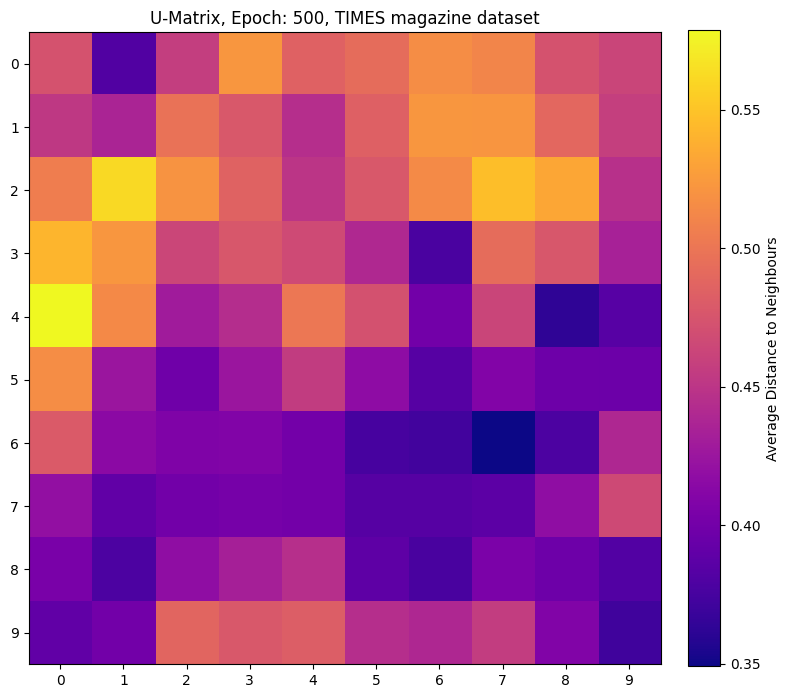

In [8]:
visualize_u_matrix(som, 500, "TIMES magazine")

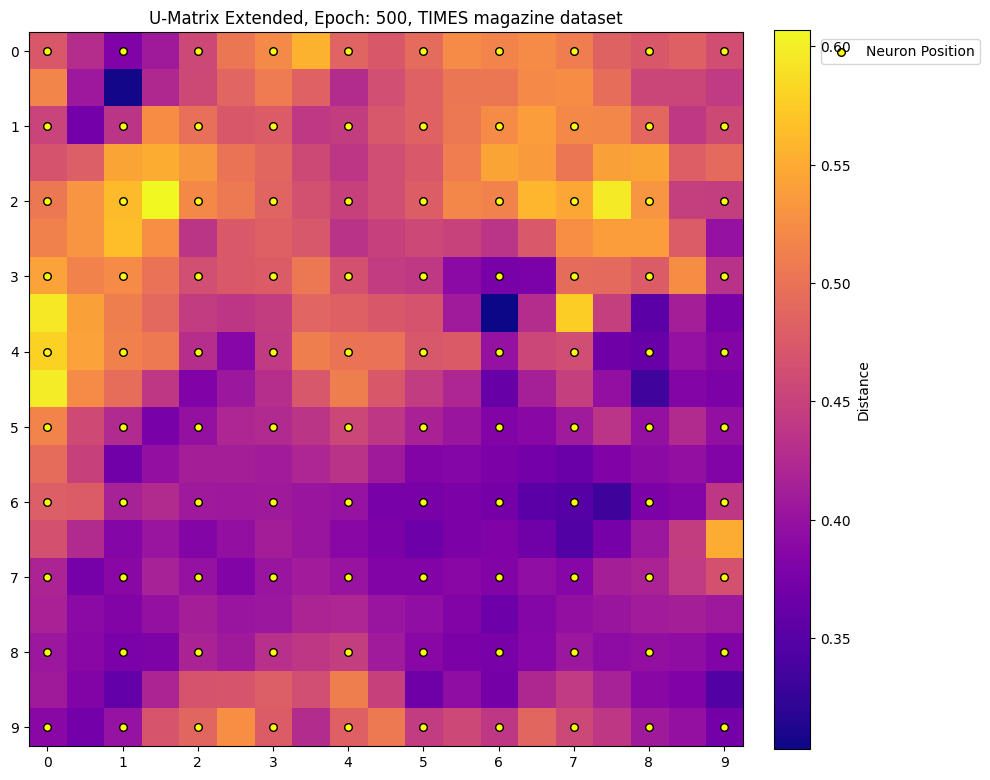

In [9]:
visualize_u_matrix_extended(som, 500, "TIMES magazine")

In [10]:
terms = tfidf_vectorizer.get_feature_names_out()

In [11]:
for i in range(som.map_rows):
    for j in range(som.map_cols):
        print(f"Node ({i},{j}):", end=" ")
        som.describe_node(X_tfidf, y, terms, (i,j), 10, True)
        print()

Node (0,0): Top 10 words: diem, viet, saigon, nam, minh, general, south, buddhist, cong, nhu, 
Samples: T434.html, T480.html, T498.html, T518.html, T533.html, T559.html, 

Node (0,1): Top 10 words: viet, cong, nam, south, diem, saigon, helicopt, red, govern, vietnames, 
Samples: T029.html, T051.html, T053.html, T228.html, T269.html, T313.html, T464.html, T470.html, T545.html, 

Node (0,2): Top 10 words: viet, south, nam, we, cong, into, or, were, africa, vietnames, 
Samples: T148.html, T202.html, 

Node (0,3): Top 10 words: south, africa, white, black, african, verwoerd, apartheid, by, chief, minist, 
Samples: T110.html, T254.html, T391.html, T427.html, T442.html, T475.html, T525.html, T538.html, 

Node (0,4): Top 10 words: kenya, kenyatta, mau, white, african, somalia, uhuru, africa, feder, jomo, 
Samples: T151.html, T159.html, T302.html, T321.html, T403.html, T546.html, 

Node (0,5): Top 10 words: kenya, island, kenyatta, uhuru, malaysia, borneo, feder, popul, british, independ, 
Sam